In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = load_breast_cancer(as_frame=True)
df =  data['data']
df['target'] = data['target']
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

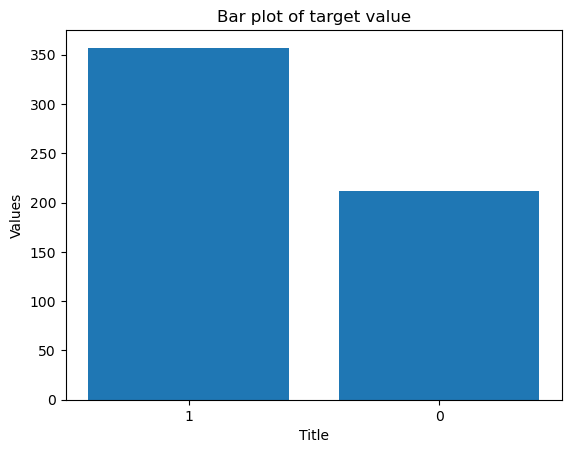

In [4]:
value_count = df['target'].value_counts()
plt.title("Bar plot of target value")
plt.xlabel("Title")
plt.ylabel("Values")
plt.bar(['1','0'], value_count)
plt.show()

In [5]:
x = df.drop(columns='target')
y = df['target']

In [6]:
from sklearn.feature_selection import mutual_info_classif
l = mutual_info_classif(x,y)
k = pd.DataFrame()
k['features'] = x.columns
k['values'] = l
x = x[k.sort_values('values',ascending=False)['features'][:5]]
y = y

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.80,random_state=42)
logistic = LogisticRegression()
logistic.fit(x_train, y_train)
ypred = logistic.predict(x_test)

/home/ansh-yadav/.miniconda3/envs/jupyter-lab/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       166
           1       0.96      0.92      0.94       290

    accuracy                           0.92       456
   macro avg       0.91      0.93      0.92       456
weighted avg       0.93      0.92      0.92       456

